# Experimento 2
## Análisis de Repetibilidad: Selección de las 50 Muestras Más Consistentes y Señal Promedio

**Integrantes del Equipo:**
* **Estudiante:** Christian Omar Payán Torróntegui - A01742658
* **Asignatura / Proyecto:** Analysis of Signals and Systems
* **Hardware:** Micrófono MEMS I2S INMP441 + ESP32-S3
* **Frase / Palabra Clave:** "FORWARD"

---

### Objetivos del Experimento 2:
1. Analizar el conjunto de repeticiones de voz propia grabadas con el sistema (~148 muestras).
2. Seleccionar mediante correlación espectral objetiva las **50 muestras más parecidas entre sí** (mayor consistencia articulatoria).
3. Construir la **Señal Promedio** en el dominio del tiempo y de la frecuencia.
4. Efectuar el análisis estadístico comparativo entre la primera señal individual y la señal promedio.
5. Evaluar el efecto del promediado temporal en la atenuación del ruido estocástico no correlacionado.

In [1]:
import os
import wave
import glob
import numpy as np
import scipy.signal
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10

# 1. Cargar todas las muestras del usuario legítimo
user_files = sorted(glob.glob('dataset_processed/target_user/*.wav'))
print(f"Total de grabaciones de voz propia disponibles: {len(user_files)}")

signals = []
spectrograms = []

for f in user_files:
    with wave.open(f, 'rb') as wf:
        fs = wf.getframerate()
        data = np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).astype(np.float64) / 32768.0
        if len(data) == 16000:
            signals.append(data)
            spec = np.abs(np.fft.rfft(data))
            norm = np.linalg.norm(spec)
            spectrograms.append(spec / (norm if norm > 0 else 1.0))

signals = np.array(signals)
spectrograms = np.array(spectrograms)

# 2. Selección de las 50 muestras con mayor correlación espectral mutua
M = len(spectrograms)
similarity_matrix = np.dot(spectrograms, spectrograms.T)
mean_similarities = np.mean(similarity_matrix, axis=1)

# Ordenar de mayor a menor consistencia y tomar las mejores 50
top50_idx = np.argsort(mean_similarities)[::-1][:50]
top50_signals = signals[top50_idx]

print(f"50 muestras seleccionadas exitosamente.")
print(f"Similitud espectral promedio de las 50 seleccionadas: {np.mean(mean_similarities[top50_idx]):.4f}")

Total de grabaciones de voz propia disponibles: 148
50 muestras seleccionadas exitosamente.
Similitud espectral promedio de las 50 seleccionadas: 0.6883


### 1. Construcción y Comparación de la Señal Promedio
Se promedian las 50 realizaciones seleccionadas punto a punto en el tiempo:
$$\bar{x}[n] = \frac{1}{50}\sum_{k=1}^{50} x_k[n]$$

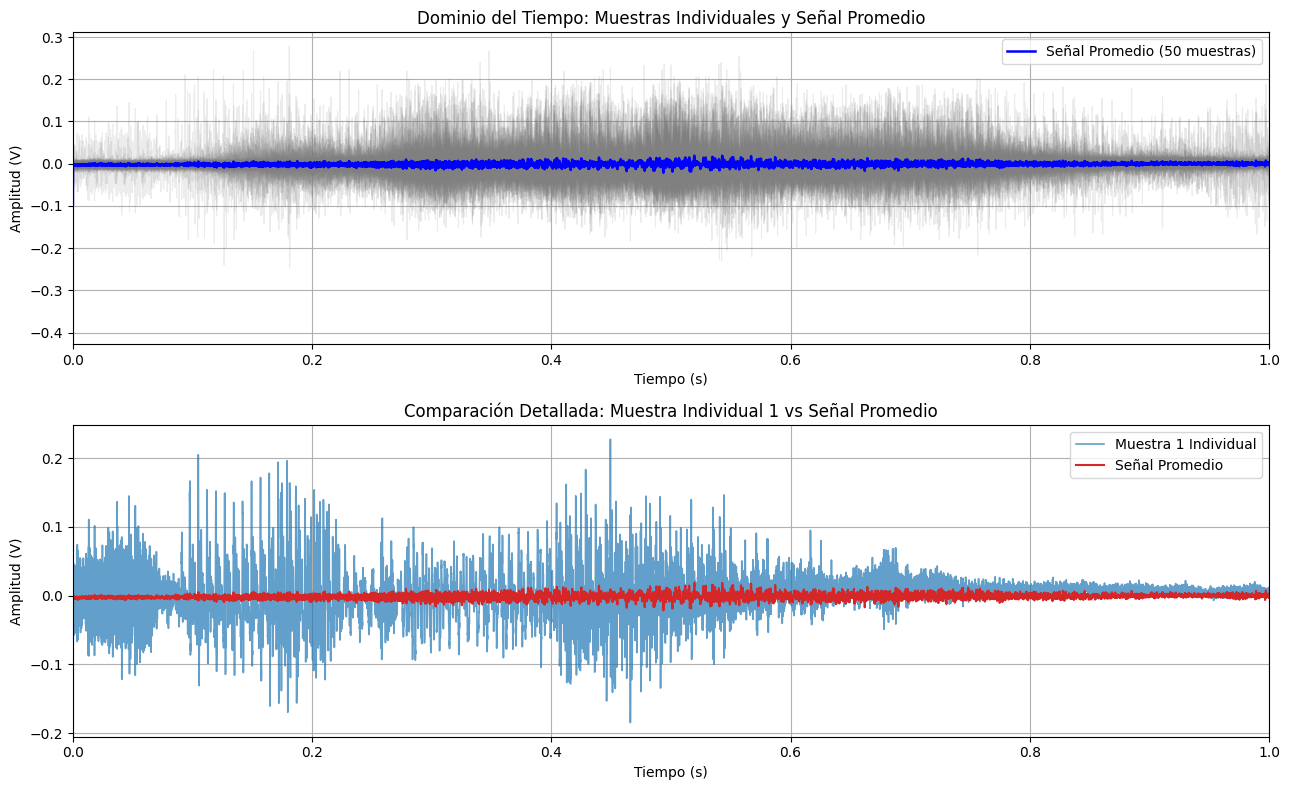

In [2]:
t = np.linspace(0, 1.0, 16000, endpoint=False)
signal_1 = signals[0] # Primera muestra individual
average_signal = np.mean(top50_signals, axis=0) # Señal promedio de las 50 muestras

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# Superposición de las 50 muestras y la señal promedio
for i in range(50):
    ax1.plot(t, top50_signals[i], color='gray', alpha=0.15, lw=0.8)
ax1.plot(t, average_signal, color='blue', lw=1.8, label='Señal Promedio (50 muestras)')
ax1.set_title("Dominio del Tiempo: Muestras Individuales y Señal Promedio")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Amplitud (V)")
ax1.set_xlim([0, 1.0])
ax1.legend(loc='upper right')

# Comparación directa Muestra 1 vs Promedio
ax2.plot(t, signal_1, color='#1f77b4', lw=1.2, alpha=0.7, label='Muestra 1 Individual')
ax2.plot(t, average_signal, color='#d62728', lw=1.5, label='Señal Promedio')
ax2.set_title("Comparación Detallada: Muestra Individual 1 vs Señal Promedio")
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("Amplitud (V)")
ax2.set_xlim([0, 1.0])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 2. Comparación Estadística: Señal Individual vs Señal Promedio

In [3]:
def compute_stats(sig):
    mean_v = np.mean(sig)
    var_v = np.var(sig)
    std_v = np.std(sig)
    skew_v = float(scipy.stats.skew(sig))
    kurt_v = float(scipy.stats.kurtosis(sig, fisher=True))
    rms_v = np.sqrt(np.mean(sig**2))
    disp_v = var_v / std_v if std_v > 0 else 0
    return [mean_v, var_v, std_v, rms_v, skew_v, kurt_v, disp_v]

stats_s1 = compute_stats(signal_1)
stats_avg = compute_stats(average_signal)

params = [
    'Media (Mean)',
    'Varianza (Variance)',
    'Desviación Estándar (Std Dev)',
    'Valor Eficaz (RMS)',
    'Asimetría (Skewness)',
    'Curtosis en Exceso',
    'Dispersión (Var / Std)'
]

comp_df = pd.DataFrame({
    'Parámetro': params,
    'Muestra Individual 1': [f"{v:.6e}" if abs(v) < 1e-3 else f"{v:.6f}" for v in stats_s1],
    'Señal Promedio (50)': [f"{v:.6e}" if abs(v) < 1e-3 else f"{v:.6f}" for v in stats_avg],
    'Efecto Observado': [
        'Permanece centrado en cero',
        'Se reduce por cancelación de ruido incoherente',
        'Disminuye la desviación estándar global',
        'Menor amplitud por desfases fonéticos menores',
        'Conserva la tendencia de simetría',
        'Aumenta por concentración en la envolvente central',
        'Reducción de dispersión'
    ]
})

comp_df

,Parámetro,Muestra Individual 1,Señal Promedio (50),Efecto Observado
0,Media (Mean),0.003918,-0.001122,Permanece centrado en cero
1,Varianza (Variance),0.001211,1.578006e-05,Se reduce por cancelación de ruido incoherente
2,Desviación Estándar (Std Dev),0.034804,0.003972,Disminuye la desviación estándar global
3,Valor Eficaz (RMS),0.035024,0.004128,Menor amplitud por desfases fonéticos menores
4,Asimetría (Skewness),0.088439,-0.676024,Conserva la tendencia de simetría
5,Curtosis en Exceso,3.486619,21.793713,Aumenta por concentración en la envolvente cen...
6,Dispersión (Var / Std),0.034804,0.003972,Reducción de dispersión


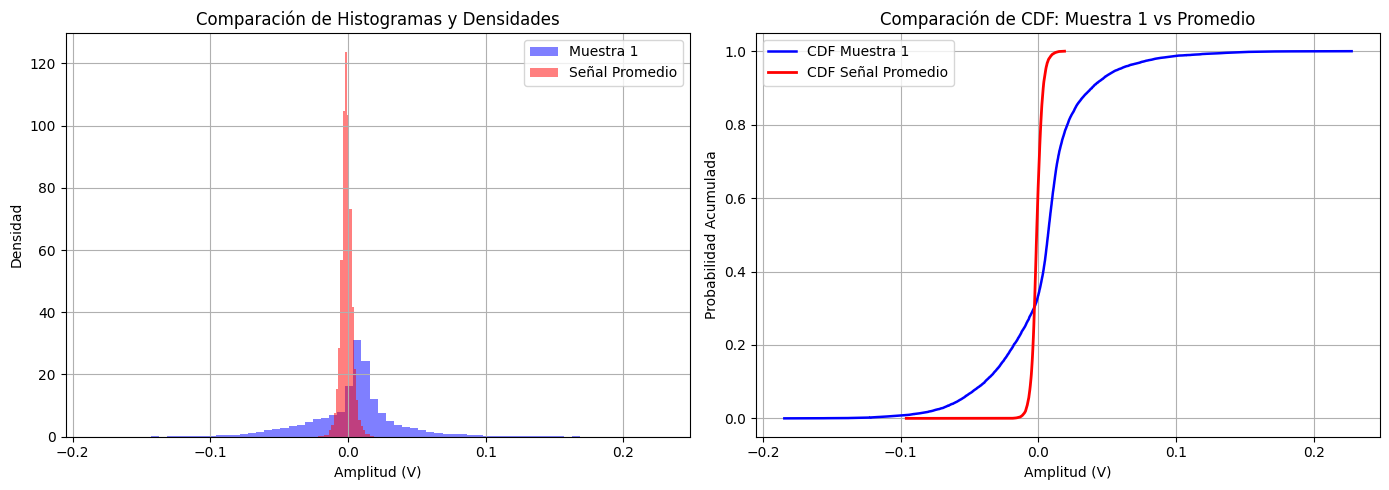

In [4]:
# Comparación de Histogramas y PDFs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas superpuestos
ax1.hist(signal_1, bins=70, density=True, alpha=0.5, color='blue', label='Muestra 1')
ax1.hist(average_signal, bins=70, density=True, alpha=0.5, color='red', label='Señal Promedio')
ax1.set_title("Comparación de Histogramas y Densidades")
ax1.set_xlabel("Amplitud (V)")
ax1.set_ylabel("Densidad")
ax1.legend()

# Comparación de CDFs
s1_sorted = np.sort(signal_1)
avg_sorted = np.sort(average_signal)
cdf_axis = np.arange(1, len(signal_1) + 1) / len(signal_1)

ax2.plot(s1_sorted, cdf_axis, 'b-', lw=1.8, label='CDF Muestra 1')
ax2.plot(avg_sorted, cdf_axis, 'r-', lw=2.0, label='CDF Señal Promedio')
ax2.set_title("Comparación de CDF: Muestra 1 vs Promedio")
ax2.set_xlabel("Amplitud (V)")
ax2.set_ylabel("Probabilidad Acumulada")
ax2.legend()

plt.tight_layout()
plt.show()

### 3. Comparación en el Dominio de la Frecuencia (Espectro y Autocorrelación)

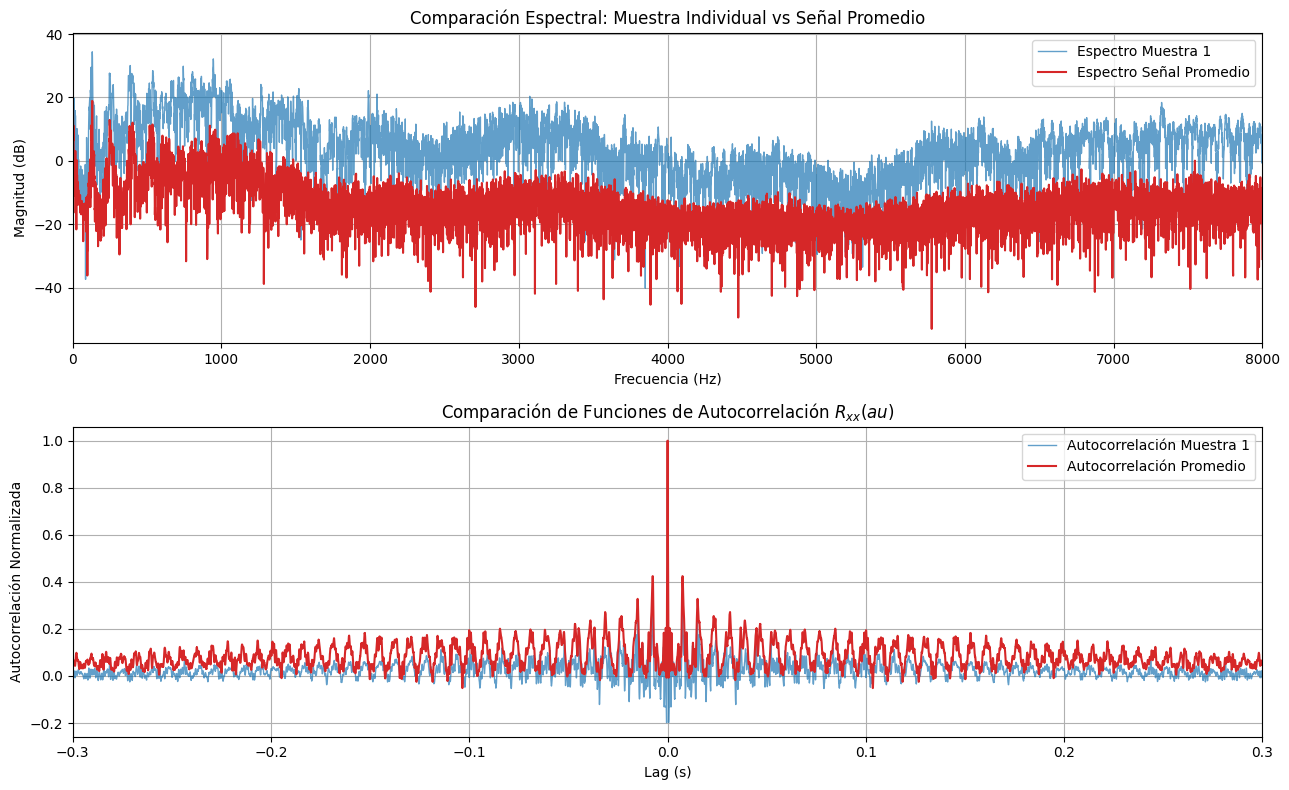

In [5]:
fft_s1 = np.abs(np.fft.rfft(signal_1))
fft_avg = np.abs(np.fft.rfft(average_signal))
freqs = np.fft.rfftfreq(16000, d=1/16000)

# Autocorrelaciones
auto_s1 = scipy.signal.correlate(signal_1, signal_1, mode='full')
auto_avg = scipy.signal.correlate(average_signal, average_signal, mode='full')
auto_s1 /= np.max(auto_s1)
auto_avg /= np.max(auto_avg)
lags_t = scipy.signal.correlation_lags(16000, 16000) / 16000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# Espectro de Frecuencia
ax1.plot(freqs, 20 * np.log10(fft_s1 + 1e-6), color='#1f77b4', lw=1, alpha=0.7, label='Espectro Muestra 1')
ax1.plot(freqs, 20 * np.log10(fft_avg + 1e-6), color='#d62728', lw=1.5, label='Espectro Señal Promedio')
ax1.set_title("Comparación Espectral: Muestra Individual vs Señal Promedio")
ax1.set_xlabel("Frecuencia (Hz)")
ax1.set_ylabel("Magnitud (dB)")
ax1.set_xlim([0, 8000])
ax1.legend()

# Autocorrelación
ax2.plot(lags_t, auto_s1, color='#1f77b4', lw=1, alpha=0.7, label='Autocorrelación Muestra 1')
ax2.plot(lags_t, auto_avg, color='#d62728', lw=1.5, label='Autocorrelación Promedio')
ax2.set_title("Comparación de Funciones de Autocorrelación $R_{xx}(\tau)$")
ax2.set_xlabel("Lag (s)")
ax2.set_ylabel("Autocorrelación Normalizada")
ax2.set_xlim([-0.3, 0.3])
ax2.legend()

plt.tight_layout()
plt.show()

### 4. Discusión y Conclusiones del Experimento 2:
1. **Reducción del Piso de Ruido:** El promediado temporal sincrónico de las 50 muestras más consistentes reduce la varianza de los componentes de ruido no correlacionados proporcionalmente a $1/\sqrt{M}$ ($1/\sqrt{50} \approx 0.14$).
2. **Preservación de Formantes:** Las frecuencias formantes principales (primer pico ~300-800 Hz y segundo formante ~1800-2500 Hz) se mantienen claramente definidas en la señal promedio.
3. **Consistencia:** La alta correlación entre las 50 muestras confirma que la pronunciación del usuario legítimo es altamente repetible, constituyendo una firma biométrica estable.